Using device: cpu
-> 입력 이미지 텐서 Shape: torch.Size([64, 1, 28, 28])
-> 정답 레이블 텐서 Shape: torch.Size([64])

--- 모델 학습 및 검증 시작 ---
Epoch [1/5] | Train Loss: 0.1470, Train Acc: 95.45% | Val Loss: 0.0557, Val Acc: 98.28%
Epoch [2/5] | Train Loss: 0.0465, Train Acc: 98.50% | Val Loss: 0.0557, Val Acc: 98.30%
Epoch [3/5] | Train Loss: 0.0325, Train Acc: 98.95% | Val Loss: 0.0436, Val Acc: 98.69%
Epoch [4/5] | Train Loss: 0.0228, Train Acc: 99.29% | Val Loss: 0.0523, Val Acc: 98.52%
Epoch [5/5] | Train Loss: 0.0202, Train Acc: 99.33% | Val Loss: 0.0417, Val Acc: 98.81%


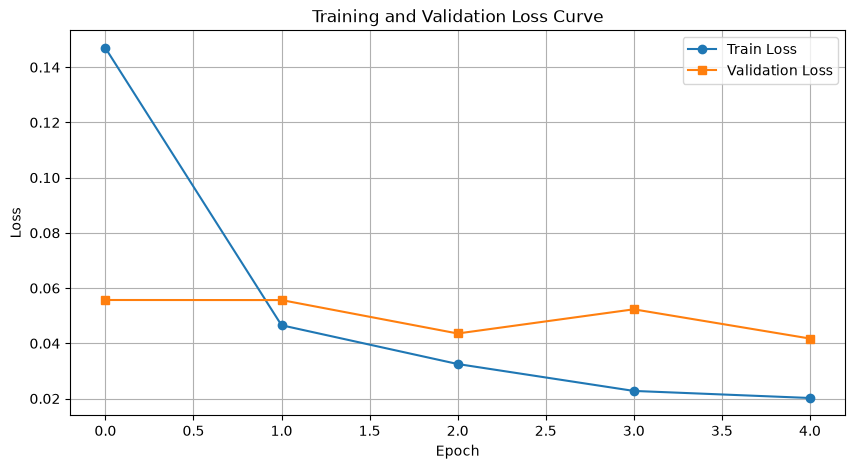


[Test 결과] 최종 테스트 정확도(Accuracy): 99.08%


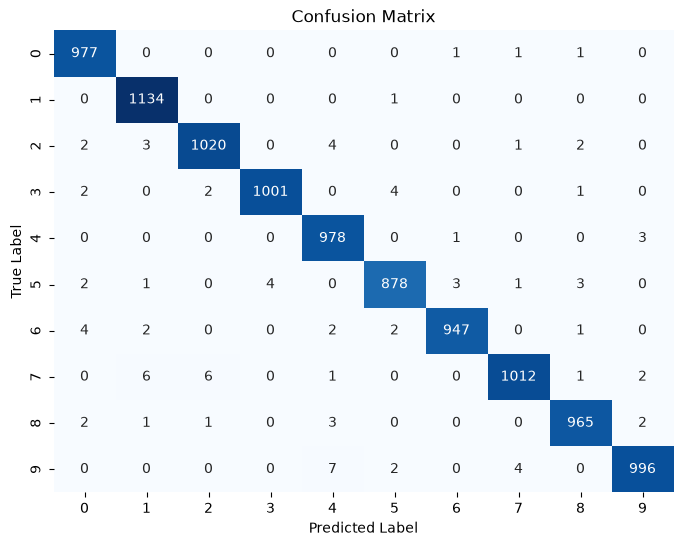


[오분류 분석] 테스트 데이터 중 틀린 이미지 개수: 92개


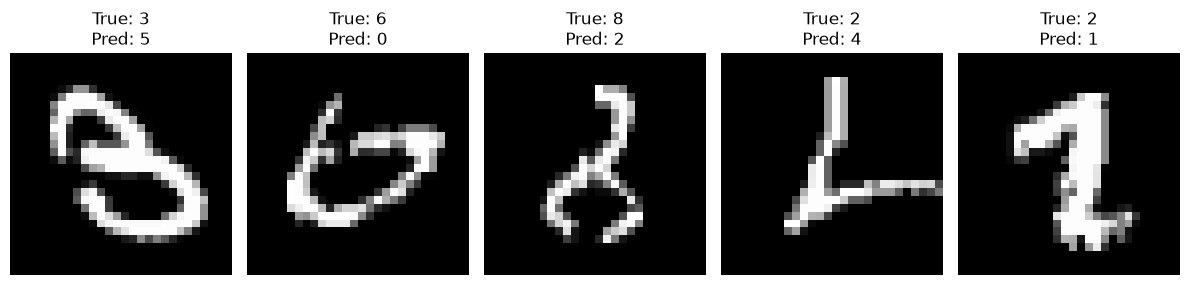


[모델 저장 완료] 학습된 모델 가중치가 'mnist_cnn_model.pth'로 저장되었습니다.


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# ==========================================
# 1. 학습 장치(Device) 설정
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


# ==========================================
# 2. 전처리 정의 및 MNIST Dataset 로드
# ==========================================
transform = transforms.Compose([
    transforms.ToTensor(),                          # ③ Tensor 변환 (이미지 데이터를 PyTorch Tensor로 변환)
    transforms.Normalize((0.1307,), (0.3081,))      # MNIST 데이터셋의 평균 및 표준편차 정규화
])

# ① MNIST Dataset 로드 (학습/검증용 및 테스트용 데이터셋 다운로드 및 로드)
full_train_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)


# ==========================================
# 3. 데이터셋 분할 및 DataLoader 구성
# ==========================================
train_size = 50000
val_size = 10000
train_dataset, val_dataset = torch.utils.data.random_split(
    full_train_dataset, [train_size, val_size]
)

# ④ DataLoader 구성 (미니배치 단위 로드)
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=1000, shuffle=False)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)

# ② 이미지 데이터 확인 (첫 번째 배치 샘플 형태 출력)
examples = enumerate(train_loader)
batch_idx, (sample_data, sample_targets) = next(examples)
print(f"-> 입력 이미지 텐서 Shape: {sample_data.shape}")
print(f"-> 정답 레이블 텐서 Shape: {sample_targets.shape}")


# ==========================================
# 4. CNN 모델 구현 (Conv, Pooling, FC Layer 구성)
# ==========================================
# ⑤ CNN 모델 구현
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        # ⑥ Convolution Layer 구성 및 ⑦ Pooling Layer 구성 (1번째)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=1, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # ⑥ Convolution Layer 구성 및 ⑦ Pooling Layer 구성 (2번째)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # ⑧ Fully Connected Layer 구성
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool2(x)
        
        x = x.view(-1, 64 * 7 * 7)
        
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN().to(device)


# ==========================================
# 5. Loss Function 및 Optimizer 구성
# ==========================================
criterion = nn.CrossEntropyLoss()                  # ⑨ Loss Function 구성
optimizer = optim.Adam(model.parameters(), lr=0.001)  # ⑩ Optimizer 구성


# ==========================================
# 6. Training Loop 및 Validation 구현
# ==========================================
num_epochs = 5
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

print("\n--- 모델 학습 및 검증 시작 ---")
for epoch in range(num_epochs):
    # ⑪ Training Loop 구현
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = 100 * correct_train / total_train  # ⑭ Accuracy 계산 (Train)
    train_losses.append(epoch_train_loss)
    train_accuracies.append(epoch_train_acc)
    
    # ⑫ Validation 구현
    model.eval()
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = 100 * correct_val / total_val  # ⑭ Accuracy 계산 (Validation)
    val_losses.append(epoch_val_loss)
    val_accuracies.append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] | "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")


# ==========================================
# 7. Loss 시각화
# ==========================================
# ⑮ Loss 시각화
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(True)
plt.savefig('loss_curve.png')
plt.show()


# ==========================================
# 8. Test 구현 및 Accuracy 계산
# ==========================================
# ⑬ Test 구현
model.eval()
correct_test = 0
total_test = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()  # ⑭ Accuracy 계산 (Test)
        
        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

test_accuracy = 100 * correct_test / total_test
print(f"\n[Test 결과] 최종 테스트 정확도(Accuracy): {test_accuracy:.2f}%")


# ==========================================
# 9. Confusion Matrix 작성 및 시각화
# ==========================================
# ⑯ Confusion Matrix 작성
conf_matrix = confusion_matrix(all_targets, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()


# ==========================================
# 10. 오분류 이미지 분석 (Misclassified Image Analysis)
# ==========================================
# ⑰ 오분류 이미지 분석
all_preds_np = np.array(all_preds)
all_targets_np = np.array(all_targets)
misclassified_idx = np.where(all_preds_np != all_targets_np)[0]

print(f"\n[오분류 분석] 테스트 데이터 중 틀린 이미지 개수: {len(misclassified_idx)}개")

plt.figure(figsize=(12, 5))
for i, idx in enumerate(misclassified_idx[:5]):
    image, true_label = test_dataset[idx]
    pred_label = all_preds_np[idx]
    
    plt.subplot(1, 5, i + 1)
    img_np = image.squeeze().numpy() * 0.3081 + 0.1307
    plt.imshow(img_np, cmap='gray')
    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis('off')
plt.tight_layout()
plt.savefig('misclassified_images.png')
plt.show()


# ==========================================
# 11. 모델 저장 (Model Saving)
# ==========================================
# ⑱ 모델 저장
torch.save(model.state_dict(), 'mnist_cnn_model.pth')
print("\n[모델 저장 완료] 학습된 모델 가중치가 'mnist_cnn_model.pth'로 저장되었습니다.")